# Local Ricci - Predictive Experiment (CIFAR-10)

**Dataset**: CIFAR-10 - Cars (class 1) vs Planes (class 0)
*(same binary pair used in the local-Ricci paper)*

**Hypothesis**: The local Ricci coefficient measured during the first ~40 epochs
predicts long-term accuracy.

This is the LOCAL-ONLY half of the predictive experiment. It:
1. Trains 45 architectures for 200 epochs, saving activations for the first
   `RICCI_EPOCHS` epochs.
2. Computes the local Ricci coefficient (per-vertex Pearson, then averaged) at
   each early epoch.
3. K-sweeps local Ricci on the saved activations (no retraining).
4. Reports correlations of early local Ricci with long-term accuracy.

The companion notebooks share the same `OUTPUT_DIR`:
- `global_ricci_predictive_experiment_cifar10.ipynb` -- global Ricci on the same
  saved activations (run *after* this notebook finishes training).
- `local_vs_global_comparison_cifar10.ipynb` -- combined comparison plots.


In [1]:
import os, time, json, copy
import numpy as np
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, TensorDataset
from scipy.sparse import csr_matrix, lil_matrix
from scipy.sparse import triu as sp_triu
from scipy.sparse.csgraph import dijkstra
from sklearn.neighbors import kneighbors_graph
from scipy.stats import pearsonr, spearmanr, kendalltau
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from tqdm.auto import tqdm

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')


Device: cpu


/home/zkus/Desktop/izzettin-ismail-cihan/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/zkus/Desktop/izzettin-ismail-cihan/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [2]:
# -- Reproducibility --
SEED = 42
import random
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
try:
    torch.use_deterministic_algorithms(True, warn_only=True)
except Exception:
    pass

# -- Epoch budget --
TOTAL_EPOCHS = 200
RICCI_EPOCHS = 40

# -- LOCAL Ricci kNN (Wankmuller et al.: k = 5% of |X_test|) --
K_FRAC = 0.05

# -- Curvature type --
CURVATURE_TYPE = 'Augmented-Forman-Ricci'

# -- Optimiser --
LR = 0.001
BATCH_SIZE = 512

# -- Architecture grid (45 nets) --
FLAT_DEPTHS       = [4, 5, 6, 7, 8, 9, 10, 11, 12]
FLAT_WIDTHS       = [16, 32, 64, 128]
BOTTLENECK_DEPTHS = [4, 5, 6, 7, 8, 9, 10, 11, 12]
BOTTLENECK_WIDTH  = 128

ARCHITECTURES = []
for d in FLAT_DEPTHS:
    for w in FLAT_WIDTHS:
        ARCHITECTURES.append((f'flat_{d}_{w}', 'flat', d, w))
for d in BOTTLENECK_DEPTHS:
    ARCHITECTURES.append((f'bottleneck_{d}_{BOTTLENECK_WIDTH}', 'bottleneck', d, BOTTLENECK_WIDTH))

print(f'Total architectures : {len(ARCHITECTURES)}')
print(f'Flat : {len(FLAT_DEPTHS)*len(FLAT_WIDTHS)}   Bottleneck : {len(BOTTLENECK_DEPTHS)}')

# -- Output paths (the GLOBAL and COMPARISON notebooks read from this same dir!) --
DRIVE_BASE  = '/home/zkus/Desktop/izzettin-ismail-cihan/18052026'
OUTPUT_DIR  = os.path.join(DRIVE_BASE, 'local_vs_global_ricci_cifar10_v1')
MODELS_DIR  = os.path.join(OUTPUT_DIR, 'models')
CKPT_PATH   = os.path.join(OUTPUT_DIR, 'checkpoint.json')

for d in [OUTPUT_DIR, MODELS_DIR]:
    os.makedirs(d, exist_ok=True)

print(f'Output root : {OUTPUT_DIR}')


Total architectures : 45
Flat : 36   Bottleneck : 9
Output root : /home/zkus/Desktop/izzettin-ismail-cihan/18052026/local_vs_global_ricci_cifar10_v1


In [3]:
# -- CIFAR-10: Cars (class=1) vs Planes (class=0) --
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2023, 0.1994, 0.2010)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

train_data = torchvision.datasets.CIFAR10(
    root='./data', train=True,  download=True, transform=transform)
test_data  = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform)


def load_cifar_pair(dataset, class_a=0, class_b=1, balance=None):
    targets = torch.tensor(dataset.targets)
    mask    = (targets == class_a) | (targets == class_b)
    indices = mask.nonzero(as_tuple=True)[0]

    imgs = torch.tensor(dataset.data[indices.numpy()], dtype=torch.float32)
    imgs = imgs.permute(0, 3, 1, 2) / 255.0
    mean = torch.tensor(CIFAR_MEAN).view(1, 3, 1, 1)
    std  = torch.tensor(CIFAR_STD ).view(1, 3, 1, 1)
    imgs = (imgs - mean) / std

    labels = targets[indices].float()
    labels = (labels == class_b).float()

    if balance is not None:
        idx0 = (labels == 0).nonzero(as_tuple=True)[0]
        idx1 = (labels == 1).nonzero(as_tuple=True)[0]
        k = min(balance, len(idx0), len(idx1))
        sel = torch.cat((idx0[:k], idx1[:k]))
        imgs = imgs[sel]
        labels = labels[sel]

    return imgs.to(device), labels.to(device)


X_train, y_train = load_cifar_pair(train_data, balance=None)
X_test,  y_test  = load_cifar_pair(test_data,  balance=500)

def make_train_loader(seed=SEED):
    train_gen = torch.Generator()
    train_gen.manual_seed(seed)
    return DataLoader(
        TensorDataset(X_train, y_train),
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=train_gen,
        num_workers=0,
    )

INPUT_DIM = X_train.shape[1] * X_train.shape[2] * X_train.shape[3]

print(f'Train : {X_train.shape}   Test : {X_test.shape}')
print(f'Input dim (flattened) : {INPUT_DIM}')
print(f'Class balance -- Train : {y_train.mean():.3f}   Test : {y_test.mean():.3f}')

K = max(1, int(round(K_FRAC * X_test.shape[0])))
print(f'LOCAL kNN k = {K}  ({K_FRAC*100:.1f}% of {X_test.shape[0]} samples)')


/home/zkus/Desktop/izzettin-ismail-cihan/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train : torch.Size([10000, 3, 32, 32])   Test : torch.Size([1000, 3, 32, 32])
Input dim (flattened) : 3072
Class balance -- Train : 0.500   Test : 0.500
LOCAL kNN k = 50  (5.0% of 1000 samples)


In [4]:
def get_bottleneck_widths(depth, max_width):
    mid = depth // 2
    widths = []
    for i in range(depth):
        dist_from_edge = min(i, depth - 1 - i)
        reduction = 2 ** (mid - dist_from_edge) if dist_from_edge < mid else 1
        widths.append(max(max_width // reduction, 8))
    return widths


class DNN(nn.Module):
    def __init__(self, input_dim, layer_widths=None, hidden_units=None, depth=None):
        super().__init__()
        if layer_widths is None:
            layer_widths = [hidden_units] * depth
        self.flatten = nn.Flatten()
        dims = [input_dim] + layer_widths + [1]
        layers = []
        for i in range(len(dims) - 1):
            lin = nn.Linear(dims[i], dims[i + 1])
            nn.init.kaiming_normal_(lin.weight, nonlinearity='relu')
            nn.init.zeros_(lin.bias)
            layers.append(lin)
        self.layers = nn.ModuleList(layers)

    def forward(self, x):
        x = self.flatten(x)
        for layer in self.layers[:-1]:
            x = torch.relu(layer(x))
        return self.layers[-1](x)

    def features(self, x):
        x = self.flatten(x)
        feats = [x.detach().cpu().numpy()]
        for layer in self.layers[:-1]:
            x = torch.relu(layer(x))
            feats.append(x.detach().cpu().numpy())
        feats.append(torch.sigmoid(self.layers[-1](x)).detach().cpu().numpy())
        return feats


def build_model(arch_type, depth, width):
    if arch_type == 'bottleneck':
        return DNN(input_dim=INPUT_DIM,
                   layer_widths=get_bottleneck_widths(depth, width)).to(device)
    return DNN(input_dim=INPUT_DIM, hidden_units=width, depth=depth).to(device)


_m = build_model('flat', 5, 64)
print(f'Flat 5/64 first layer: {_m.layers[0].in_features} -> {_m.layers[0].out_features}')
assert _m.layers[0].in_features == INPUT_DIM, 'Input dim mismatch!'
del _m
print(f'DNN defined  (input_dim={INPUT_DIM})')


Flat 5/64 first layer: 3072 -> 64
DNN defined  (input_dim=3072)


In [5]:
def accuracy_fn(y_true, y_pred):
    return torch.eq(y_true, y_pred).sum().item() / len(y_pred)

def train_one_epoch(model, loader, optimizer, loss_fn):
    model.train()
    total = 0.0
    for Xb, yb in loader:
        logits = model(Xb).squeeze()
        loss   = loss_fn(logits, yb)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total += loss.item() * len(Xb)
    return total / len(loader.dataset)

def evaluate(model, X, y):
    model.eval()
    with torch.inference_mode():
        logits = model(X).squeeze()
        preds  = torch.round(torch.sigmoid(logits))
        acc    = accuracy_fn(y, preds)
        loss   = nn.BCEWithLogitsLoss()(logits, y).item()
    return acc, loss

print('\u2705 Training utilities defined')


✅ Training utilities defined


In [6]:
def compute_augmented_forman_ricci(A):
    A       = csr_matrix(A)
    degrees = A @ np.ones(A.shape[0])
    A2      = A @ A
    Ric     = lil_matrix(A.shape, dtype=np.int32)
    rows, cols = sp_triu(A, k=1).nonzero()
    for i, j in zip(rows, cols):
        Ric[i, j] = 4 - degrees[i] - degrees[j] + 3 * A2[i, j]
        Ric[j, i] = Ric[i, j]
    return Ric.tocsr()

def compute_forman_ricci(A):
    A       = csr_matrix(A)
    degrees = A @ np.ones(A.shape[0])
    Ric     = lil_matrix(A.shape, dtype=np.int32)
    rows, cols = sp_triu(A, k=1).nonzero()
    for i, j in zip(rows, cols):
        Ric[i, j] = 4 - degrees[i] - degrees[j]
        Ric[j, i] = Ric[i, j]
    return Ric.tocsr()

def compute_approx_ollivier_ricci(A):
    A       = csr_matrix(A)
    degrees = A @ np.ones(A.shape[0])
    A2      = A @ A
    Ric     = lil_matrix(A.shape, dtype=np.float32)
    rows, cols = sp_triu(A, k=1).nonzero()
    for i, j in zip(rows, cols):
        t  = A2[i, j]; di, dj = degrees[i], degrees[j]
        Ric[i, j] = (0.5*(t/max(di,dj))
                     - 0.5*(max(0, 1-1/di-1/dj-t/min(di,dj))
                            + max(0, 1-1/di-1/dj-t/max(di,dj))
                            - t/max(di,dj)))
        Ric[j, i] = Ric[i, j]
    return Ric.tocsr()

def compute_curvature(A, curv):
    if   curv == 'Forman-Ricci':           return compute_forman_ricci(A)
    elif curv == 'Augmented-Forman-Ricci': return compute_augmented_forman_ricci(A)
    elif curv == 'Approx-Ollivier-Ricci':  return compute_approx_ollivier_ricci(A)
    else: raise ValueError(f'Unknown curvature: {curv}')

def compute_ricci_from_features(features, k, curv='Augmented-Forman-Ricci'):
    """Layer Ricci coefficients (paper Section 3.2).
    features : [input_acts, hidden_1, ..., hidden_L].
    Returns  : np.ndarray of shape (len(features)-1,)
    """
    depth      = len(features)
    kNN_graphs = []
    for feat in features:
        g = kneighbors_graph(feat, k, mode='connectivity', include_self=False)
        kNN_graphs.append(g.maximum(g.T))
    apsps      = [dijkstra(csgraph=g, directed=False, unweighted=True,
                           return_predecessors=False) for g in kNN_graphs]
    curvatures = [compute_curvature(kNN_graphs[i], curv) for i in range(depth - 1)]
    layer_ricci = np.empty(depth - 1)
    for i in range(depth - 1):
        sc, eta = [], []
        for x in range(len(features[0])):
            S1 = kNN_graphs[i][x].indices
            ec, connected = 0, True
            for y in S1:
                if apsps[i+1][x, y] == np.inf:
                    connected = False
                else:
                    ec += apsps[i+1][x, y] - apsps[i][x, y]
            if connected:
                sc.append(np.divide(curvatures[i][x].sum(),
                                    kNN_graphs[i][x].count_nonzero()))
                eta.append(ec / len(S1))
        layer_ricci[i] = pearsonr(sc, eta)[0] if len(sc) >= 2 else np.nan
    return layer_ricci

print('\u2705 Curvature functions defined')


✅ Curvature functions defined


In [7]:
def load_json(path, default):
    if os.path.exists(path):
        with open(path) as f:
            return json.load(f)
    return default

def save_json(path, obj):
    tmp = path + '.tmp'
    with open(tmp, 'w') as f:
        json.dump(obj, f, indent=2)
        f.flush()
        os.fsync(f.fileno())
    os.replace(tmp, path)

def save_activations(epoch_dir, acts):
    os.makedirs(epoch_dir, exist_ok=True)
    for i, act in enumerate(acts):
        path = os.path.join(epoch_dir, f'layer_{i}.npy')
        np.save(path, act)
    dirfd = os.open(epoch_dir, os.O_RDONLY)
    try:
        os.fsync(dirfd)
    finally:
        os.close(dirfd)

print('IO / checkpoint utilities defined (flush-safe)')


IO / checkpoint utilities defined (flush-safe)


In [8]:
# ============================================================================
# MAIN TRAINING LOOP -- CIFAR-10 Cars vs Planes  (LOCAL Ricci only)
# ============================================================================

ckpt      = load_json(CKPT_PATH, {'completed': []})
completed = set(ckpt['completed'])

summary_path = os.path.join(OUTPUT_DIR, 'summary.json')
summary      = load_json(summary_path, [])

t_start = time.time()

for arch_idx, (name, arch_type, depth, width) in enumerate(ARCHITECTURES):

    if name in completed:
        print(f'[{arch_idx+1:2d}/{len(ARCHITECTURES)}] {name} -- skipped (checkpoint)')
        continue

    print(f'\n[{arch_idx+1:2d}/{len(ARCHITECTURES)}] {name}'
          f'  type={arch_type}  depth={depth}  width={width}')

    arch_dir = os.path.join(MODELS_DIR, name)
    os.makedirs(arch_dir, exist_ok=True)

    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    train_loader = make_train_loader(SEED)

    model     = build_model(arch_type, depth, width)
    loss_fn   = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    epoch_history            = []
    early_local_ricci_values = []

    for epoch in range(TOTAL_EPOCHS):

        train_loss          = train_one_epoch(model, train_loader, optimizer, loss_fn)
        test_acc, test_loss = evaluate(model, X_test,  y_test)
        train_acc, _        = evaluate(model, X_train, y_train)

        epoch_entry = {
            'epoch':      epoch,
            'train_acc':  float(train_acc),
            'test_acc':   float(test_acc),
            'train_loss': float(train_loss),
            'test_loss':  float(test_loss),
        }

        if epoch < RICCI_EPOCHS:
            model.eval()
            with torch.inference_mode():
                feats = model.features(X_test)   # [input, h1..hL, sigmoid_out]

            if len(feats) < 3:
                raise ValueError(f'{name}: need >=3 feature layers, got {len(feats)}')

            layer_ricci = compute_ricci_from_features(feats, K, curv=CURVATURE_TYPE)
            avg_ricci   = float(np.nanmean(layer_ricci))
            early_local_ricci_values.append(avg_ricci)

            epoch_entry['avg_ricci']   = avg_ricci
            epoch_entry['layer_ricci'] = layer_ricci.tolist()

            ep_dir = os.path.join(arch_dir, f'epoch_{epoch:04d}')
            save_activations(ep_dir, feats)
            np.save(os.path.join(ep_dir, 'layer_ricci.npy'), layer_ricci)
            np.save(os.path.join(ep_dir, 'metrics.npy'),
                    np.array([train_acc, test_acc, train_loss, test_loss]))

            print(f'  ep {epoch:3d}  train={train_acc:.4f}  test={test_acc:.4f}'
                  f'  loc={avg_ricci:+.4f}')

        else:
            ep_dir = os.path.join(arch_dir, f'epoch_{epoch:04d}')
            os.makedirs(ep_dir, exist_ok=True)
            np.save(os.path.join(ep_dir, 'metrics.npy'),
                    np.array([train_acc, test_acc, train_loss, test_loss]))

            if (epoch + 1) % 50 == 0 or epoch == TOTAL_EPOCHS - 1:
                print(f'  ep {epoch:3d}  train={train_acc:.4f}  test={test_acc:.4f}')

        heartbeat = {
            'name':      name,
            'arch_idx':  arch_idx,
            'epoch':     epoch,
            'train_acc': float(train_acc),
            'test_acc':  float(test_acc),
        }
        save_json(os.path.join(OUTPUT_DIR, 'heartbeat.json'), heartbeat)

        epoch_history.append(epoch_entry)

    torch.save(model.state_dict(), os.path.join(arch_dir, 'model_weights_final.pth'))
    save_json(os.path.join(arch_dir, 'epoch_history.json'), epoch_history)

    early_ricci_score = float(np.nanmean(early_local_ricci_values))
    all_test_accs     = [e['test_acc'] for e in epoch_history]
    long_term_acc     = float(np.mean(all_test_accs))
    final_acc         = float(epoch_history[-1]['test_acc'])
    best_acc          = float(max(all_test_accs))
    best_acc_epoch    = int(np.argmax(all_test_accs))

    entry = {
        'name':                  name,
        'type':                  arch_type,
        'depth':                 depth,
        'width':                 width,
        'early_ricci_score':     early_ricci_score,
        'early_ricci_per_epoch': early_local_ricci_values,
        'k_local':               K,
        'long_term_acc':         long_term_acc,
        'final_acc':             final_acc,
        'best_acc':              best_acc,
        'best_acc_epoch':        best_acc_epoch,
    }
    summary.append(entry)
    save_json(summary_path, summary)

    completed.add(name)
    save_json(CKPT_PATH, {'completed': list(completed)})
    try:
        dirfd = os.open(OUTPUT_DIR, os.O_RDONLY)
        os.fsync(dirfd)
        os.close(dirfd)
    except Exception:
        pass

    print(f'  -> early_ricci={early_ricci_score:+.4f}  '
          f'long_term_acc={long_term_acc:.4f}  final_acc={final_acc:.4f}')

    del model, optimizer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(f'\nTraining complete in {(time.time()-t_start)/3600:.2f}h')
print(f'   {len(summary)} architectures saved to {summary_path}')


[ 1/45] flat_4_16 -- skipped (checkpoint)
[ 2/45] flat_4_32 -- skipped (checkpoint)
[ 3/45] flat_4_64 -- skipped (checkpoint)
[ 4/45] flat_4_128 -- skipped (checkpoint)
[ 5/45] flat_5_16 -- skipped (checkpoint)
[ 6/45] flat_5_32 -- skipped (checkpoint)
[ 7/45] flat_5_64 -- skipped (checkpoint)
[ 8/45] flat_5_128 -- skipped (checkpoint)
[ 9/45] flat_6_16 -- skipped (checkpoint)
[10/45] flat_6_32 -- skipped (checkpoint)
[11/45] flat_6_64 -- skipped (checkpoint)
[12/45] flat_6_128 -- skipped (checkpoint)
[13/45] flat_7_16 -- skipped (checkpoint)
[14/45] flat_7_32 -- skipped (checkpoint)
[15/45] flat_7_64 -- skipped (checkpoint)
[16/45] flat_7_128 -- skipped (checkpoint)
[17/45] flat_8_16 -- skipped (checkpoint)
[18/45] flat_8_32 -- skipped (checkpoint)
[19/45] flat_8_64 -- skipped (checkpoint)
[20/45] flat_8_128 -- skipped (checkpoint)
[21/45] flat_9_16 -- skipped (checkpoint)
[22/45] flat_9_32 -- skipped (checkpoint)
[23/45] flat_9_64 -- skipped (checkpoint)
[24/45] flat_9_128 -- skipped

In [9]:
# ── Correlations: Early Ricci vs Long-Term Accuracy ──────────────────────────
summary = load_json(os.path.join(OUTPUT_DIR, 'summary.json'), [])
if not summary:
    print('Run the training cell first.')
else:
    ricci_arr = np.array([r['early_ricci_score'] for r in summary])
    lt_arr    = np.array([r['long_term_acc']     for r in summary])

    # Negate ricci so rank 1 = most negative = best geometric signal,
    # matching rank 1 = highest accuracy. Correlations are then positive
    # when the hypothesis holds.
    ricci_rank_arr = -ricci_arr

    pear_r,  pear_p  = pearsonr(ricci_rank_arr, lt_arr)
    spear_r, spear_p = spearmanr(ricci_rank_arr, lt_arr)
    kend_tau, kend_p = kendalltau(ricci_rank_arr, lt_arr)

    print('═' * 60)
    print('CORRELATION: Ricci Rank  vs  Accuracy Rank')
    print('(rank by -early_ricci vs rank by long_term_acc)')
    print('CIFAR-10  Cars vs Planes')
    print('═' * 60)
    print(f'  Pearson  r   = {pear_r:+.4f}   p = {pear_p:.4f}')
    print(f'  Spearman rho = {spear_r:+.4f}   p = {spear_p:.4f}')
    print(f' s Kendall  tau = {kend_tau:+.4f}   p = {kend_p:.4f}')
    print('═' * 60)
    print()
    print('Interpretation:')
    print('  r / rho / tau > 0  →  more negative early Ricci predicts higher accuracy')
    print('  r / rho / tau ≈ 0  →  no predictive relationship')

    corr_results = {
        'dataset':        'CIFAR-10 Cars vs Planes',
        'sign_convention': 'positive = more negative ricci predicts higher acc',
        'pearson_r':   pear_r,  'pearson_p':   pear_p,
        'spearman_r':  spear_r, 'spearman_p':  spear_p,
        'kendall_tau': kend_tau,'kendall_p':   kend_p,
        'n':           len(summary),
    }
    save_json(os.path.join(OUTPUT_DIR, 'correlation_results.json'), corr_results)
    print(f'\nSaved → {os.path.join(OUTPUT_DIR, "correlation_results.json")}')


════════════════════════════════════════════════════════════
CORRELATION: Ricci Rank  vs  Accuracy Rank
(rank by -early_ricci vs rank by long_term_acc)
CIFAR-10  Cars vs Planes
════════════════════════════════════════════════════════════
  Pearson  r   = +0.2305   p = 0.1276
  Spearman rho = +0.2572   p = 0.0881
 s Kendall  tau = +0.1636   p = 0.1130
════════════════════════════════════════════════════════════

Interpretation:
  r / rho / tau > 0  →  more negative early Ricci predicts higher accuracy
  r / rho / tau ≈ 0  →  no predictive relationship

Saved → /home/zkus/Desktop/izzettin-ismail-cihan/18052026/local_vs_global_ricci_cifar10_v1/correlation_results.json


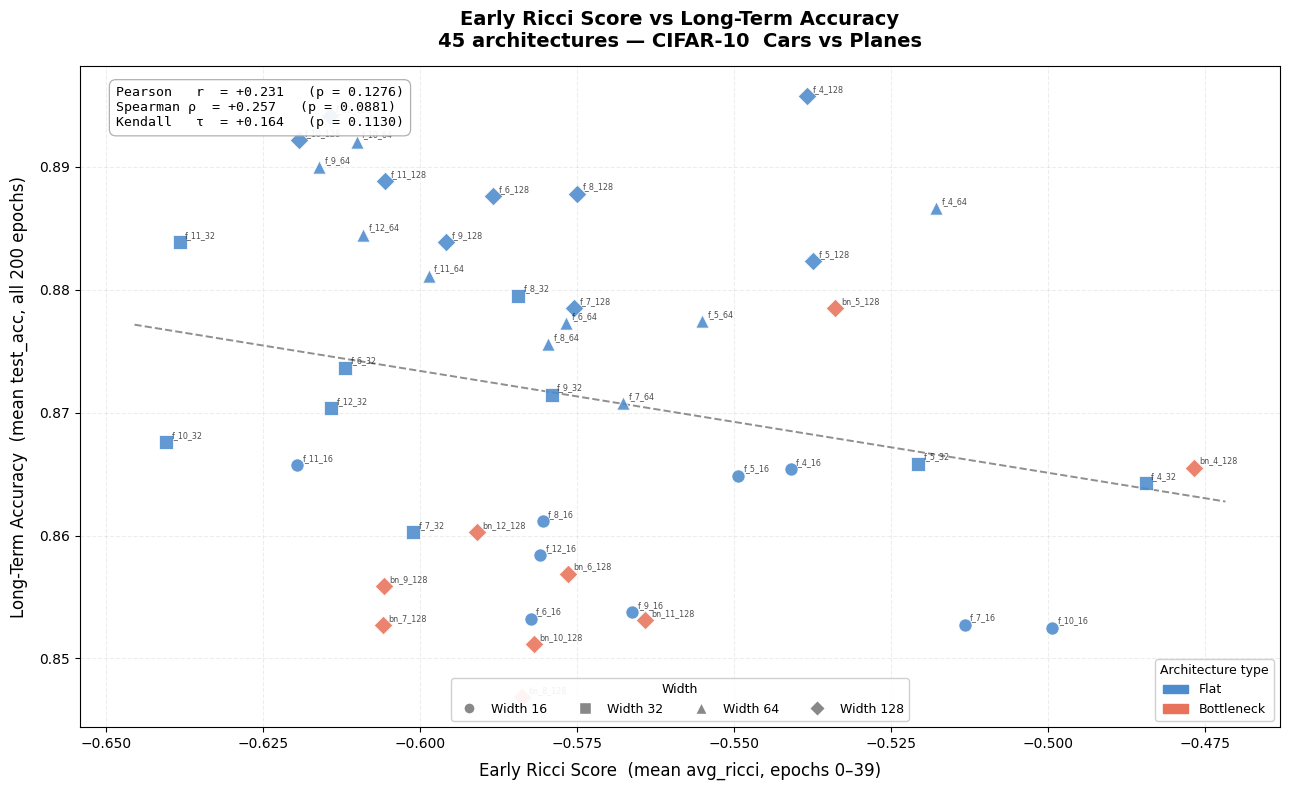

✅ Saved → /home/zkus/Desktop/izzettin-ismail-cihan/18052026/local_vs_global_ricci_cifar10_v1/ricci_vs_longterm_acc_scatter.png


In [10]:
# ── Scatter: Early Ricci vs Long-Term Accuracy ────────────────────────────────
import matplotlib.patches as mpatches

summary = load_json(os.path.join(OUTPUT_DIR, 'summary.json'), [])
corr    = load_json(os.path.join(OUTPUT_DIR, 'correlation_results.json'), {})

if not summary:
    print('Run training and correlation cells first.')
else:
    ricci_scores = np.array([r['early_ricci_score'] for r in summary])
    lt_accs      = np.array([r['long_term_acc']     for r in summary])
    arch_types   = [r['type']  for r in summary]
    names        = [r['name']  for r in summary]

    type_color   = {'flat': '#4C8BCC', 'bottleneck': '#E8735A'}
    width_marker = {16: 'o', 32: 's', 64: '^', 128: 'D'}

    fig, ax = plt.subplots(figsize=(13, 8))

    for r in summary:
        ax.scatter(r['early_ricci_score'], r['long_term_acc'],
                   color=type_color[r['type']], marker=width_marker[r['width']],
                   s=90, alpha=0.88, edgecolors='white', linewidths=0.6, zorder=3)

    m, b    = np.polyfit(ricci_scores, lt_accs, 1)
    x_range = np.linspace(ricci_scores.min() - 0.005, ricci_scores.max() + 0.005, 300)
    ax.plot(x_range, m * x_range + b, color='#333333',
            lw=1.4, ls='--', alpha=0.55, zorder=2)

    for r in summary:
        short = r['name'].replace('bottleneck_', 'bn_').replace('flat_', 'f_')
        ax.annotate(short, (r['early_ricci_score'], r['long_term_acc']),
                    xytext=(4, 3), textcoords='offset points',
                    fontsize=5.8, alpha=0.80, color='#222222')

    if corr:
        box = (f"Pearson   r  = {corr['pearson_r']:+.3f}   (p = {corr['pearson_p']:.4f})\n"
               f"Spearman ρ  = {corr['spearman_r']:+.3f}   (p = {corr['spearman_p']:.4f})\n"
               f"Kendall   τ  = {corr['kendall_tau']:+.3f}   (p = {corr['kendall_p']:.4f})")
        ax.text(0.03, 0.97, box, transform=ax.transAxes, fontsize=9.5,
                verticalalignment='top', family='monospace',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                          edgecolor='#AAAAAA', linewidth=0.9, alpha=0.92))

    type_legend = [mpatches.Patch(color='#4C8BCC', label='Flat'),
                   mpatches.Patch(color='#E8735A', label='Bottleneck')]
    width_legend = [
        plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#888', markersize=8, label='Width 16'),
        plt.Line2D([0],[0], marker='s', color='w', markerfacecolor='#888', markersize=8, label='Width 32'),
        plt.Line2D([0],[0], marker='^', color='w', markerfacecolor='#888', markersize=8, label='Width 64'),
        plt.Line2D([0],[0], marker='D', color='w', markerfacecolor='#888', markersize=8, label='Width 128'),
    ]
    leg1 = ax.legend(handles=type_legend, loc='lower right',
                     fontsize=9, title='Architecture type', title_fontsize=9, framealpha=0.92)
    ax.add_artist(leg1)
    ax.legend(handles=width_legend, loc='lower center',
              fontsize=9, title='Width', title_fontsize=9, framealpha=0.92, ncol=4)

    ax.set_xlabel(f'Early Ricci Score  (mean avg_ricci, epochs 0–{RICCI_EPOCHS-1})',
                  fontsize=12, labelpad=8)
    ax.set_ylabel(f'Long-Term Accuracy  (mean test_acc, all {TOTAL_EPOCHS} epochs)',
                  fontsize=12, labelpad=8)
    ax.set_title('Early Ricci Score vs Long-Term Accuracy\n'
                 f'45 architectures — CIFAR-10  Cars vs Planes',
                 fontsize=14, fontweight='bold', pad=14)
    ax.grid(True, alpha=0.22, linestyle='--')
    ax.set_axisbelow(True)

    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, 'ricci_vs_longterm_acc_scatter.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'\u2705 Saved → {save_path}')


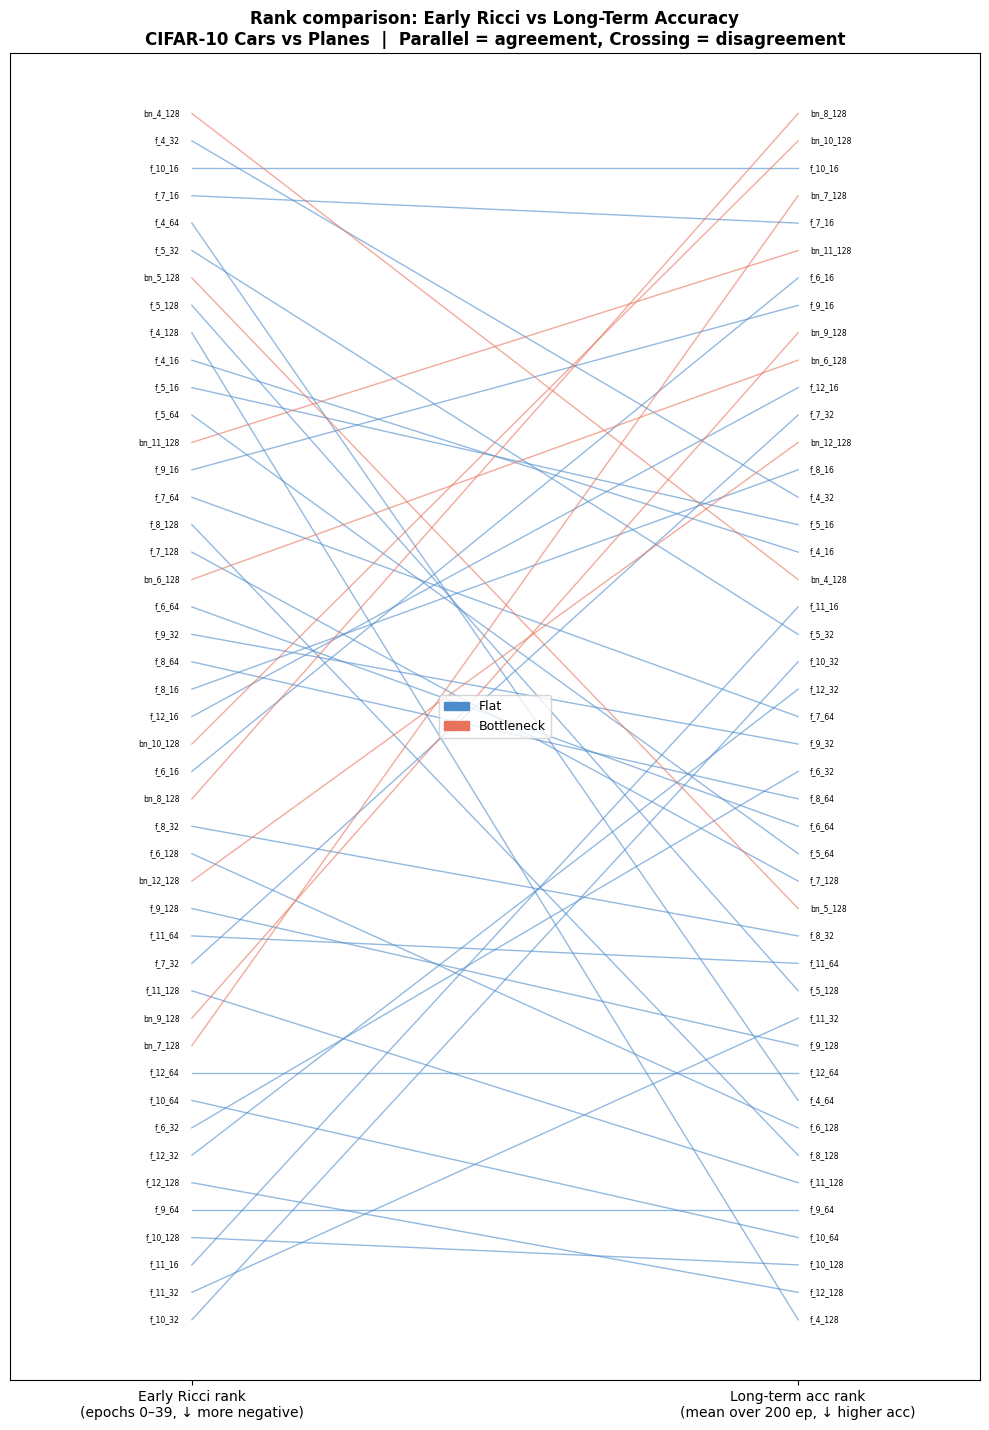

✅ Saved → /home/zkus/Desktop/izzettin-ismail-cihan/18052026/local_vs_global_ricci_cifar10_v1/rank_comparison.png


In [11]:
# ── Rank comparison plot ──────────────────────────────────────────────────────
import matplotlib.patches as mpatches

summary = load_json(os.path.join(OUTPUT_DIR, 'summary.json'), [])
if not summary:
    print('Run training cell first.')
else:
    ricci_scores = np.array([r['early_ricci_score'] for r in summary])
    lt_accs      = np.array([r['long_term_acc']      for r in summary])
    names        = [r['name'] for r in summary]
    arch_types   = [r['type'] for r in summary]

    ricci_ranks   = np.argsort(ricci_scores)
    acc_ranks     = np.argsort(lt_accs)[::-1]
    ricci_rank_of = {names[i]: int(pos) for pos, i in enumerate(ricci_ranks)}
    acc_rank_of   = {names[i]: int(pos) for pos, i in enumerate(acc_ranks)}

    type_color = {'flat': '#4C8BCC', 'bottleneck': '#E8735A'}
    n   = len(names)
    fig, ax = plt.subplots(figsize=(10, max(8, n * 0.32)))

    for i, (name, atype) in enumerate(zip(names, arch_types)):
        rr = ricci_rank_of[name]
        ar = acc_rank_of[name]
        ax.plot([0, 1], [rr, ar], color=type_color[atype], alpha=0.6, lw=1.0)
        short = name.replace('bottleneck_','bn_').replace('flat_','f_')
        ax.text(-0.02, rr, short, ha='right', va='center', fontsize=5.5)
        ax.text( 1.02, ar, short, ha='left',  va='center', fontsize=5.5)

    ax.set_xlim(-0.3, 1.3)
    ax.set_xticks([0, 1])
    ax.set_xticklabels([f'Early Ricci rank\n(epochs 0–{RICCI_EPOCHS-1}, ↓ more negative)',
                         f'Long-term acc rank\n(mean over {TOTAL_EPOCHS} ep, ↓ higher acc)'],
                        fontsize=10)
    ax.set_yticks([])
    ax.set_title('Rank comparison: Early Ricci vs Long-Term Accuracy\n'
                 'CIFAR-10 Cars vs Planes  |  Parallel = agreement, Crossing = disagreement',
                 fontsize=12, fontweight='bold')
    ax.legend(handles=[mpatches.Patch(color='#4C8BCC', label='Flat'),
                        mpatches.Patch(color='#E8735A', label='Bottleneck')],
              fontsize=9, loc='center')

    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, 'rank_comparison.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'\u2705 Saved → {save_path}')


/tmp/ipykernel_2097050/2409485130.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap       = cm.get_cmap('RdYlGn')


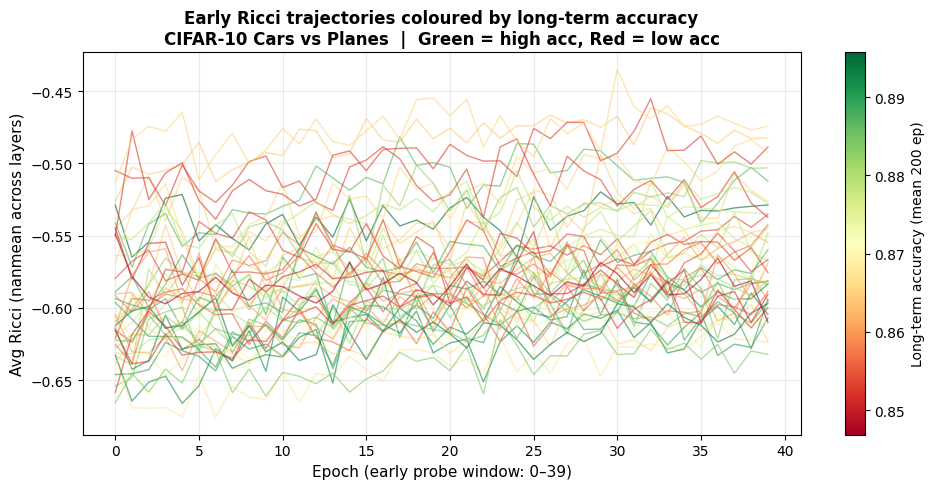

✅ Saved → /home/zkus/Desktop/izzettin-ismail-cihan/18052026/local_vs_global_ricci_cifar10_v1/early_ricci_trajectories.png


In [12]:
# ── Early Ricci trajectory plot ───────────────────────────────────────────────
summary = load_json(os.path.join(OUTPUT_DIR, 'summary.json'), [])
if not summary:
    print('Run training cell first.')
else:
    lt_accs    = np.array([r['long_term_acc'] for r in summary])
    vmin, vmax = lt_accs.min(), lt_accs.max()
    cmap       = cm.get_cmap('RdYlGn')

    fig, ax = plt.subplots(figsize=(10, 5))
    for r in summary:
        traj  = r['early_ricci_per_epoch']
        color = cmap((r['long_term_acc'] - vmin) / (vmax - vmin + 1e-9))
        ax.plot(range(len(traj)), traj, color=color, alpha=0.6, lw=1.0)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label='Long-term accuracy (mean 200 ep)')

    ax.set_xlabel(f'Epoch (early probe window: 0–{RICCI_EPOCHS-1})', fontsize=11)
    ax.set_ylabel('Avg Ricci (nanmean across layers)', fontsize=11)
    ax.set_title('Early Ricci trajectories coloured by long-term accuracy\n'
                 'CIFAR-10 Cars vs Planes  |  Green = high acc, Red = low acc',
                 fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.25)

    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, 'early_ricci_trajectories.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'\u2705 Saved → {save_path}')


In [13]:
# ── Export full results CSV ───────────────────────────────────────────────────
import csv

summary = load_json(os.path.join(OUTPUT_DIR, 'summary.json'), [])
corr    = load_json(os.path.join(OUTPUT_DIR, 'correlation_results.json'), {})

if not summary:
    print('Run training cell first.')
else:
    ricci_scores = [r['early_ricci_score'] for r in summary]
    lt_accs      = [r['long_term_acc']      for r in summary]

    # ricci_rank: rank 1 = most negative (strongest early flow)
    ricci_rank = {summary[i]['name']: int(rk) + 1
                  for rk, i in enumerate(np.argsort(ricci_scores))}
    # acc_rank: rank 1 = highest long-term accuracy
    acc_rank   = {summary[i]['name']: int(rk) + 1
                  for rk, i in enumerate(np.argsort(lt_accs)[::-1])}

    rows = []
    for r in summary:
        row = {
            'name':              r['name'],
            'type':              r['type'],
            'depth':             r['depth'],
            'width':             r['width'],
            'early_ricci_score': round(r['early_ricci_score'], 6),
            'ricci_rank':        ricci_rank[r['name']],
            'long_term_acc':     round(r['long_term_acc'], 6),
            'acc_rank':          acc_rank[r['name']],
            'final_acc':         round(r['final_acc'], 6),
            'best_acc':          round(r['best_acc'], 6),
            'best_acc_epoch':    r['best_acc_epoch'],
        }
        for ep, val in enumerate(r['early_ricci_per_epoch']):
            row[f'ricci_ep{ep}'] = round(val, 6)
        rows.append(row)

    rows.sort(key=lambda x: x['acc_rank'])

    csv_path = os.path.join(OUTPUT_DIR, 'ricci_predictive_results.csv')
    with open(csv_path, 'w', newline='') as f:
        w = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
        w.writeheader()
        w.writerows(rows)

    print(f'\u2705 Saved {len(rows)} rows → {csv_path}')

    print(f'\n{"Rank":>4}  {"Architecture":<26}  {"Early Ricci":>12}  '
          f'{"Ricci Rank":>10}  {"LT Acc":>8}')
    print('─' * 68)
    to_show = rows[:10] + [None] + rows[-10:]
    for row in to_show:
        if row is None:
            print('  ...')
            continue
        print(f'{row["acc_rank"]:>4}  {row["name"]:<26}  '
              f'{row["early_ricci_score"]:>+12.4f}  '
              f'{row["ricci_rank"]:>10}  '
              f'{row["long_term_acc"]:>8.4f}')

    if corr:
        print(f'\nCorrelations (n={corr["n"]})  —  CIFAR-10 Cars vs Planes:')
        print(f'  Pearson  r   = {corr["pearson_r"]:+.4f}  p={corr["pearson_p"]:.4f}')
        print(f'  Spearman rho = {corr["spearman_r"]:+.4f}  p={corr["spearman_p"]:.4f}')
        print(f'  Kendall  tau = {corr["kendall_tau"]:+.4f}  p={corr["kendall_p"]:.4f}')


✅ Saved 45 rows → /home/zkus/Desktop/izzettin-ismail-cihan/18052026/local_vs_global_ricci_cifar10_v1/ricci_predictive_results.csv

Rank  Architecture                 Early Ricci  Ricci Rank    LT Acc
────────────────────────────────────────────────────────────────────
   1  flat_4_128                       -0.5383          37    0.8957
   2  flat_12_128                      -0.6143           6    0.8941
   3  flat_10_128                      -0.6192           4    0.8922
   4  flat_10_64                       -0.6101           9    0.8921
   5  flat_9_64                        -0.6160           5    0.8900
   6  flat_11_128                      -0.6055          13    0.8889
   7  flat_8_128                       -0.5750          30    0.8878
   8  flat_6_128                       -0.5884          18    0.8876
   9  flat_4_64                        -0.5178          41    0.8867
  10  flat_12_64                       -0.6090          10    0.8845
  ...
  36  bottleneck_6_128             

## k-sweep on saved activations

Recompute layer-Ricci at additional `K_FRAC` values **without retraining**.
Uses the per-epoch `layer_*.npy` activations saved during training, so all
k values are evaluated on identical activations -> fair k-comparison.

Outputs:
- `summary_k{xxx}.json` per swept k (e.g. `summary_k050.json` for 5%)
- `correlation_results_k{xxx}.json` per swept k
- per-epoch `layer_ricci_k{xxx}.npy` written next to the saved activations

`summary.json` (the original training-time k) is left untouched.


In [14]:
K_FRAC_SWEEP = [0.03, 0.07]


def _layer_files(ep_dir):
    fs = [f for f in os.listdir(ep_dir)
          if f.startswith('layer_') and f.endswith('.npy')
          and not f.startswith('layer_ricci')]
    fs.sort(key=lambda s: int(s.split('_')[1].split('.')[0]))
    return [os.path.join(ep_dir, f) for f in fs]


def _tag(frac):
    return f"{int(round(frac * 1000)):03d}"


arch_dirs = sorted(d for d in os.listdir(MODELS_DIR)
                   if os.path.isdir(os.path.join(MODELS_DIR, d)))

print(f'Found {len(arch_dirs)} architectures in {MODELS_DIR}')

for frac in K_FRAC_SWEEP:
    k = max(1, int(round(frac * X_test.shape[0])))
    tag = _tag(frac)
    print(f'\n=== K_FRAC = {frac:.2%}  (k = {k}) ===')

    # per-frac checkpoint files
    sweep_ckpt_path = os.path.join(OUTPUT_DIR, f'sweep_checkpoint_k{tag}.json')
    out_summary     = os.path.join(OUTPUT_DIR, f'summary_k{tag}.json')

    # resume state if a previous run was interrupted
    sweep_ckpt = load_json(sweep_ckpt_path, {'completed': []})
    summary_k  = load_json(out_summary, [])
    completed_arch = set(sweep_ckpt.get('completed', []))

    if completed_arch:
        print(f'  resuming from checkpoint: {len(completed_arch)} '
              f'/ {len(arch_dirs)} architectures already done')

    for name in tqdm(arch_dirs, desc=f'k={k}'):
        if name in completed_arch:
            continue

        arch_dir  = os.path.join(MODELS_DIR, name)
        hist_path = os.path.join(arch_dir, 'epoch_history.json')
        if not os.path.exists(hist_path):
            continue
        epoch_history = load_json(hist_path, [])

        early_ricci_values = []
        for epoch in range(RICCI_EPOCHS):
            ep_dir = os.path.join(arch_dir, f'epoch_{epoch:04d}')
            if not os.path.isdir(ep_dir):
                continue
            paths = _layer_files(ep_dir)
            if len(paths) < 3:
                continue
            feats = [np.load(p) for p in paths]
            layer_ricci = compute_ricci_from_features(feats, k, curv=CURVATURE_TYPE)
            early_ricci_values.append(float(np.nanmean(layer_ricci)))
            np.save(os.path.join(ep_dir, f'layer_ricci_k{tag}.npy'),
                    layer_ricci)

        if not early_ricci_values:
            continue

        parts = name.split('_')
        atype, depth, width = parts[0], int(parts[1]), int(parts[2])
        all_test_accs = [e['test_acc'] for e in epoch_history]

        summary_k.append({
            'name': name, 'type': atype, 'depth': depth, 'width': width,
            'early_ricci_score':     float(np.nanmean(early_ricci_values)),
            'early_ricci_per_epoch': early_ricci_values,
            'long_term_acc':         float(np.mean(all_test_accs)),
            'final_acc':             float(epoch_history[-1]['test_acc']),
            'best_acc':              float(max(all_test_accs)),
            'best_acc_epoch':        int(np.argmax(all_test_accs)),
            'k_frac':                frac,
            'k':                     k,
        })

        # checkpoint after each architecture (atomic via save_json)
        save_json(out_summary, summary_k)
        completed_arch.add(name)
        save_json(sweep_ckpt_path, {'completed': sorted(completed_arch),
                                    'k_frac': frac, 'k': k})

    print(f'  saved -> {out_summary}  ({len(summary_k)} architectures)')

    if len(summary_k) >= 2:
        ricci_arr = np.array([r['early_ricci_score'] for r in summary_k])
        lt_arr    = np.array([r['long_term_acc']     for r in summary_k])
        ricci_rank_arr = -ricci_arr
        pr, pp = pearsonr(ricci_rank_arr, lt_arr)
        sr, sp = spearmanr(ricci_rank_arr, lt_arr)
        kt, kp = kendalltau(ricci_rank_arr, lt_arr)
        corr = {
            'k_frac': frac, 'k': k, 'n': len(summary_k),
            'sign_convention': 'positive = more negative ricci predicts higher acc',
            'pearson_r':   pr, 'pearson_p':   pp,
            'spearman_r':  sr, 'spearman_p':  sp,
            'kendall_tau': kt, 'kendall_p':   kp,
        }
        save_json(os.path.join(OUTPUT_DIR,
                               f'correlation_results_k{tag}.json'), corr)

        print(f'  Pearson  r   = {pr:+.4f}   p = {pp:.4f}')
        print(f'  Spearman rho = {sr:+.4f}   p = {sp:.4f}')
        print(f'  Kendall  tau = {kt:+.4f}   p = {kp:.4f}')

print('\nk-sweep done.')


Found 45 architectures in /home/zkus/Desktop/izzettin-ismail-cihan/18052026/local_vs_global_ricci_cifar10_v1/models

=== K_FRAC = 3.00%  (k = 30) ===
  resuming from checkpoint: 9 / 45 architectures already done


k=30: 100%|██████████| 45/45 [2:04:46<00:00, 166.37s/it]  


  saved -> /home/zkus/Desktop/izzettin-ismail-cihan/18052026/local_vs_global_ricci_cifar10_v1/summary_k030.json  (45 architectures)
  Pearson  r   = +0.2233   p = 0.1403
  Spearman rho = +0.2111   p = 0.1640
  Kendall  tau = +0.1354   p = 0.1899

=== K_FRAC = 7.00%  (k = 70) ===


k=70: 100%|██████████| 45/45 [4:52:05<00:00, 389.46s/it]  

  saved -> /home/zkus/Desktop/izzettin-ismail-cihan/18052026/local_vs_global_ricci_cifar10_v1/summary_k070.json  (45 architectures)
  Pearson  r   = +0.2050   p = 0.1768
  Spearman rho = +0.2462   p = 0.1030
  Kendall  tau = +0.1576   p = 0.1270

k-sweep done.


## Rank-based correlation table (LOCAL Ricci, all k values)

- **Ricci rank**: 1 = most negative early Ricci (strongest geometric signal)
- **Accuracy rank**: 1 = highest long-term accuracy

Aggregates `summary.json` (training-time local k) plus every `summary_k*.json`
produced by the LOCAL k-sweep cell.


In [15]:
import glob

def rank_correlation(summary_data, ricci_key='early_ricci_score'):
    arr   = np.array([r.get(ricci_key, np.nan) for r in summary_data], dtype=float)
    accs  = np.array([r['long_term_acc']        for r in summary_data], dtype=float)
    mask  = np.isfinite(arr) & np.isfinite(accs)
    if mask.sum() < 2:
        return None
    arr = arr[mask]; accs = accs[mask]
    n = len(arr)
    ricci_ranks = np.empty(n, dtype=int)
    ricci_ranks[np.argsort(arr)] = np.arange(1, n + 1)
    acc_ranks   = np.empty(n, dtype=int)
    acc_ranks[np.argsort(accs)[::-1]] = np.arange(1, n + 1)
    pr, pp = pearsonr(ricci_ranks, acc_ranks)
    sr, sp = spearmanr(ricci_ranks, acc_ranks)
    kt, kp = kendalltau(ricci_ranks, acc_ranks)
    return {'n': n,
            'pearson_r': float(pr),  'pearson_p':  float(pp),
            'spearman_r': float(sr), 'spearman_p': float(sp),
            'kendall_tau': float(kt),'kendall_p':   float(kp)}


rows = []
data = load_json(os.path.join(OUTPUT_DIR, 'summary.json'), [])
if len(data) >= 2:
    rc = rank_correlation(data)
    if rc is not None:
        rows.append({'k_label': f'training k ({K_FRAC:.1%})', **rc})

for path in sorted(glob.glob(os.path.join(OUTPUT_DIR, 'summary_k*.json'))):
    tag = os.path.basename(path).replace('summary_k', '').replace('.json', '')
    try:
        frac = int(tag) / 1000
    except ValueError:
        continue
    data = load_json(path, [])
    if len(data) < 2:
        continue
    rc = rank_correlation(data)
    if rc is not None:
        rows.append({'k_label': f'k={frac:.1%}', **rc})

header = (f"  {'k':<24} {'n':>4}  {'Pearson r':>10}  {'p_pear':>8}  "
          f"{'Spearman r':>11}  {'p_spear':>8}  "
          f"{'Kendall tau':>12}  {'p_kend':>8}")
print(header); print('-' * len(header))
for row in rows:
    print(f"  {row['k_label']:<24} {row['n']:>4}  "
          f"{row['pearson_r']:>+10.4f}  {row['pearson_p']:>8.4f}  "
          f"{row['spearman_r']:>+11.4f}  {row['spearman_p']:>8.4f}  "
          f"{row['kendall_tau']:>+12.4f}  {row['kendall_p']:>8.4f}")
if not rows:
    print('  (no LOCAL summaries found yet -- run training cell first)')

save_json(os.path.join(OUTPUT_DIR, 'rank_correlation_table_local.json'), rows)
print(f"\nSaved -> {os.path.join(OUTPUT_DIR, 'rank_correlation_table_local.json')}")
print()
print('Positive r/rho/tau: more negative early local Ricci predicts higher accuracy.')


  k                           n   Pearson r    p_pear   Spearman r   p_spear   Kendall tau    p_kend
----------------------------------------------------------------------------------------------------
  training k (5.0%)          45     +0.2572    0.0881      +0.2572    0.0881       +0.1636    0.1130
  k=3.0%                     45     +0.2111    0.1640      +0.2111    0.1640       +0.1354    0.1899
  k=7.0%                     45     +0.2462    0.1030      +0.2462    0.1030       +0.1576    0.1270

Saved -> /home/zkus/Desktop/izzettin-ismail-cihan/18052026/local_vs_global_ricci_cifar10_v1/rank_correlation_table_local.json

Positive r/rho/tau: more negative early local Ricci predicts higher accuracy.


## LOCAL Ricci -- correlation across k values

3 subplots (Pearson / Spearman / Kendall), one bar per (training-time + sweep) k value.
Significance stars: * p<0.05, ** p<0.01, *** p<0.001.


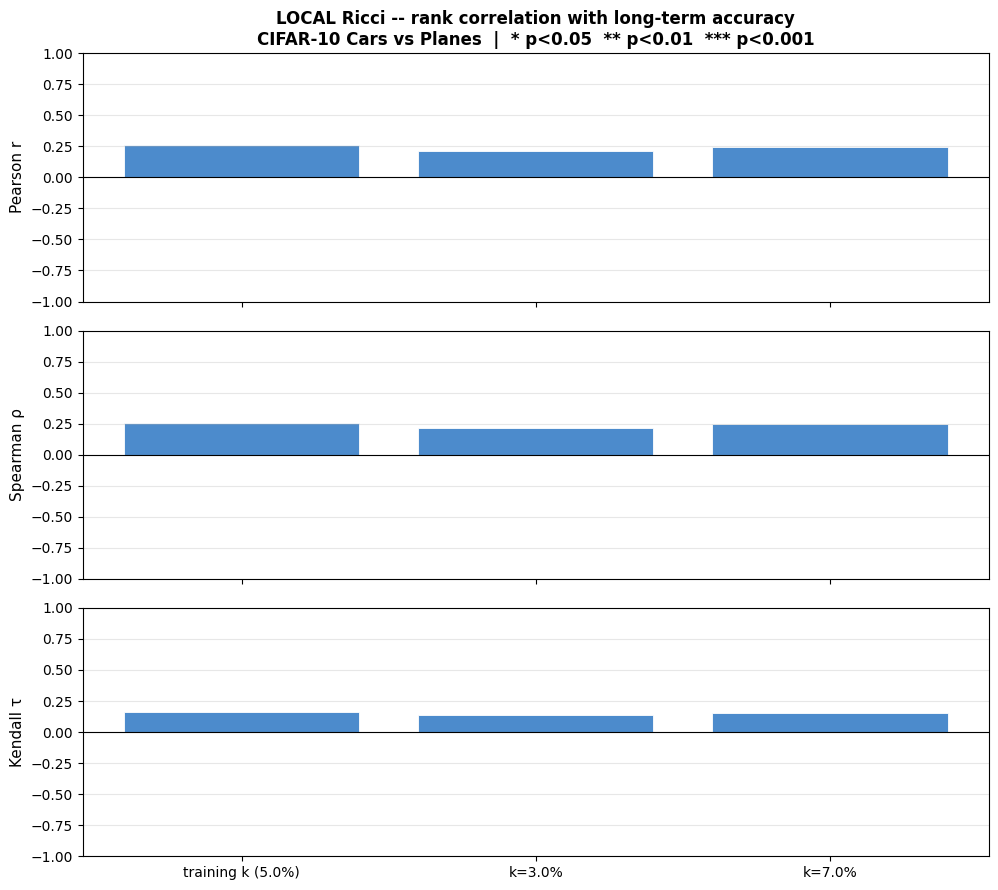

Saved -> /home/zkus/Desktop/izzettin-ismail-cihan/18052026/local_vs_global_ricci_cifar10_v1/correlation_local_across_k.png


In [16]:
rows = load_json(os.path.join(OUTPUT_DIR, 'rank_correlation_table_local.json'), [])
if not rows:
    print('Run the rank correlation table cell first.')
else:
    def _stars(p):
        if p < 0.001: return '***'
        if p < 0.01:  return '**'
        if p < 0.05:  return '*'
        return ''

    fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
    metrics = [('pearson_r',  'pearson_p',  'Pearson r'),
               ('spearman_r', 'spearman_p', 'Spearman \u03c1'),
               ('kendall_tau','kendall_p',  'Kendall \u03c4')]
    x = np.arange(len(rows))
    xticklabels = [r['k_label'] for r in rows]

    for ax, (mkey, pkey, mlabel) in zip(axes, metrics):
        vals  = [r[mkey] for r in rows]
        pvals = [r[pkey] for r in rows]
        bars  = ax.bar(x, vals, color='#4C8BCC', edgecolor='white', linewidth=0.6)
        for bar, p in zip(bars, pvals):
            s = _stars(p)
            if s:
                offset = 0.02 if bar.get_height() >= 0 else -0.05
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + offset, s,
                        ha='center', va='bottom' if bar.get_height() >= 0 else 'top',
                        fontsize=9)
        ax.axhline(0, color='black', linewidth=0.8)
        ax.set_ylabel(mlabel, fontsize=11)
        ax.set_ylim(-1, 1); ax.grid(axis='y', alpha=0.3)

    axes[-1].set_xticks(x); axes[-1].set_xticklabels(xticklabels, fontsize=10)
    axes[0].set_title('LOCAL Ricci -- rank correlation with long-term accuracy\n'
                      'CIFAR-10 Cars vs Planes  |  * p<0.05  ** p<0.01  *** p<0.001',
                      fontsize=12, fontweight='bold')

    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, 'correlation_local_across_k.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved -> {save_path}')
